### Tutorial of Reccurent Neural Networks
 * Build, train, and evaluate RNNs with torch
 * Key elements of NNs
   1. Model backbone - Feature extraction, different model types (FNN, CNN, RNN, etc.)
   2. Model head - Output layer + loss function, different learning paradigms (SL, USL, RL)
* NNs discussed in Part 2 (Advanced)
   1. Vanilla RNN for time-series prediction
   2. LSTM and GRU for time-series prediction
   3. BiLSTM for time-series prediction
   4. 1-D CNN for time-series prediction
   5. iTransformer for time-series prediction 
   6. Mixture density network for probabilistic regression
* Problems:
   1. Time-series prediction: Predict iL given vp and vs
   2. Probabilistic Regression: from sklearn.datasets import make_moons

In [1]:
%load_ext autoreload
%autoreload 2

#### 1 Load Time-Series Waveforms of DAB Converters
* Input features: vp and vs
* Output feature: iL

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
np.random.seed(42)

# Load all CSV files from the directory
import glob
file_paths = glob.glob("../../9_Case_Studies_PE/DAB_Design/Time_Domain_Modeling/Waveform/*.csv")

# Initialize empty lists to store data
X1_list = []  # Second column
X2_list = []  # Fourth column
y_list = []   # Third column


def find_zero_crossing(waveform):
    """
    Find the index where the waveform crosses from negative to positive.
    
    Args:
        waveform: numpy array or list containing the waveform data
        
    Returns:
        int: Index of the zero crossing point, or None if no crossing found
    """
    for i in range(1, len(waveform)):
        if waveform[i-1] < 0 and waveform[i] >= 0:
            return i
    return None

apply_calibration = True
# Read each CSV file and extract the required columns
np.random.seed(42)
for file_path in file_paths:
    df = pd.read_csv(file_path)
    # calibrate the data
    if apply_calibration:
        crossing_idx = find_zero_crossing(df.iloc[:, 3])
    else:
        crossing_idx = np.random.randint(0, len(df.iloc[:, 3])-201)

    X1_list.append(df.iloc[crossing_idx:crossing_idx+201, 1])  # Second column
    X2_list.append(df.iloc[crossing_idx:crossing_idx+201, 3])  # Fourth column
    y_list.append(df.iloc[crossing_idx:crossing_idx+201, 2])   # Third column

# Convert lists to numpy arrays
X1 = np.array(X1_list)[..., None]
X2 = np.array(X2_list)[..., None]
y = np.array(y_list)[..., None]

# Combine input features
X = np.concatenate((X1, X2), axis=2)

# First split: 40% train, 60% temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.6, random_state=42)

# Second split: Split temp into validation and test (50% each of the remaining 60%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Print shapes to verify split
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)


Training set shape: (40, 201, 2) (40, 201, 1)
Validation set shape: (30, 201, 2) (30, 201, 1)
Test set shape: (30, 201, 2) (30, 201, 1)


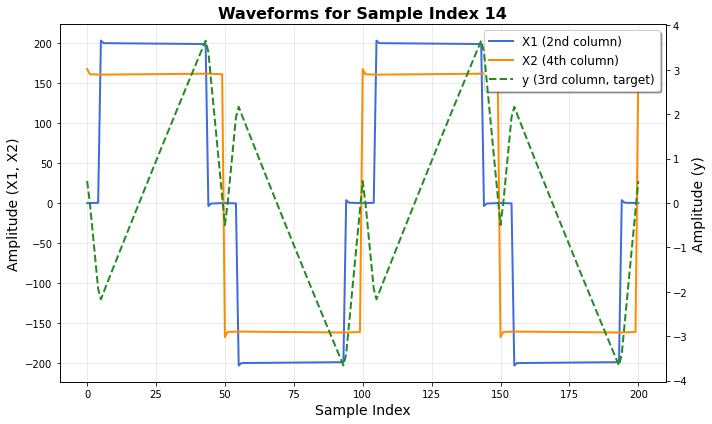

In [3]:
import matplotlib.pyplot as plt

def plot_waveforms(index, X1, X2, y):
    """
    Plot the input waveforms (X1, X2) and target (y) for a given index with professional styling.
    y is plotted on a secondary y-axis.
    """
    fig, ax1 = plt.subplots(figsize=(10, 6))
    t = np.arange(X1.shape[1])  # Assuming time axis is the sample index

    # Plot X1 and X2 on the first y-axis
    l1 = ax1.plot(t, X1[index, :, 0], label='X1 (2nd column)', color='royalblue', linewidth=2)
    l2 = ax1.plot(t, X2[index, :, 0], label='X2 (4th column)', color='darkorange', linewidth=2)
    ax1.set_xlabel('Sample Index', fontsize=14)
    ax1.set_ylabel('Amplitude (X1, X2)', fontsize=14)
    ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    # Create a second y-axis for y
    ax2 = ax1.twinx()
    l3 = ax2.plot(t, y[index, :, 0], label='y (3rd column, target)', color='forestgreen', linewidth=2, linestyle='--')
    ax2.set_ylabel('Amplitude (y)', fontsize=14)

    # Combine legends from both axes
    lines = l1 + l2 + l3
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, fontsize=12, frameon=True, shadow=True, loc='upper right')

    plt.title(f'Waveforms for Sample Index {index}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Example usage: plot the first sample
plot_waveforms(14, X1, X2, y)


#### 2 Implement feedforward NN with sliding window
* Feedforward NN does not naturally handle signal-domain data, like waveforms
* Sliding window convert the full sequence into chunks with fixed size

[FFN] Epoch 20/300, Train Loss: 6.7804, Val Loss: 6.8015
[FFN] Epoch 40/300, Train Loss: 6.6805, Val Loss: 6.3739
[FFN] Epoch 60/300, Train Loss: 6.6596, Val Loss: 6.3567
[FFN] Epoch 80/300, Train Loss: 6.6436, Val Loss: 6.5884
[FFN] Epoch 100/300, Train Loss: 6.5971, Val Loss: 5.9235
[FFN] Epoch 120/300, Train Loss: 6.5587, Val Loss: 6.2374
[FFN] Epoch 140/300, Train Loss: 6.5326, Val Loss: 6.4962
[FFN] Epoch 160/300, Train Loss: 6.5428, Val Loss: 5.9337
[FFN] Epoch 180/300, Train Loss: 6.5297, Val Loss: 6.4954
[FFN] Epoch 200/300, Train Loss: 6.5129, Val Loss: 6.5649
[FFN] Epoch 220/300, Train Loss: 6.4964, Val Loss: 6.0832
[FFN] Epoch 240/300, Train Loss: 6.4928, Val Loss: 6.2657
[FFN] Epoch 260/300, Train Loss: 6.5120, Val Loss: 5.9977
[FFN] Epoch 280/300, Train Loss: 6.4964, Val Loss: 5.9687
[FFN] Epoch 300/300, Train Loss: 6.5063, Val Loss: 6.1777
[FFN] Best Validation Loss: 5.3550
[FFN] Test Loss: 5.6767
[FFN] Training MAE: 2.0806
[FFN] Validation MAE: 2.0164
[FFN] Test MAE: 1.9

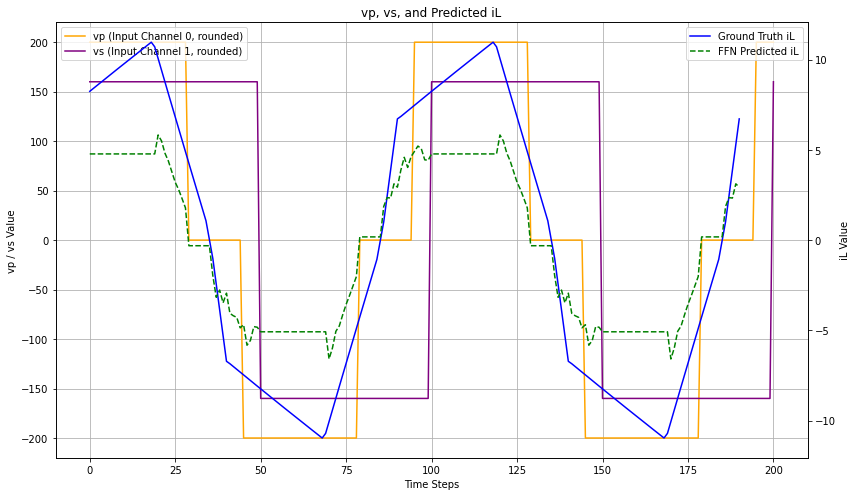

In [4]:
import torch
import torch.nn as nn
import numpy as np

# Prepare windowed data for feedforward network
def round_waveforms(X):
    X_rounded = X.copy()
    # For channel 0: round to +200, -200, or 0 V
    ch0 = X_rounded[:, :, 0]
    ch0_rounded = np.where(ch0 > 100, 200, np.where(ch0 < -100, -200, 0))
    X_rounded[:, :, 0] = ch0_rounded
    # For channel 1: round to +160, -160, or 0 V
    ch1 = X_rounded[:, :, 1]
    ch1_rounded = np.where(ch1 > 80, 160, np.where(ch1 < -80, -160, 0))
    X_rounded[:, :, 1] = ch1_rounded
    return X_rounded

def create_windowed_dataset(X, y, window_size=20):
    # Apply rounding to the waveforms as specified
    X = round_waveforms(X)
    X_windows = []
    y_windows = []
    for sample_idx in range(X.shape[0]):
        for t in range(X.shape[1] - window_size):
            X_windows.append(X[sample_idx, t:t+window_size, :])
            y_windows.append(y[sample_idx, t+window_size, :])
    X_windows = np.array(X_windows)
    y_windows = np.array(y_windows)
    return X_windows, y_windows

window_size = 10

# Prepare train, val, test sets for feedforward model
X_train_ff, y_train_ff = create_windowed_dataset(X_train, y_train, window_size)
X_val_ff, y_val_ff = create_windowed_dataset(X_val, y_val, window_size)
X_test_ff, y_test_ff = create_windowed_dataset(X_test, y_test, window_size)

# Convert to torch tensors
X_train_ff_tensor = torch.FloatTensor(X_train_ff)
y_train_ff_tensor = torch.FloatTensor(y_train_ff)
X_val_ff_tensor = torch.FloatTensor(X_val_ff)
y_val_ff_tensor = torch.FloatTensor(y_val_ff)
X_test_ff_tensor = torch.FloatTensor(X_test_ff)
y_test_ff_tensor = torch.FloatTensor(y_test_ff)

# Define Feedforward Neural Network
class FeedforwardTimeSeriesModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, output_size=1):
        super(FeedforwardTimeSeriesModel, self).__init__()
        layers = []
        in_features = input_size
        for i in range(num_layers):
            layers.append(nn.Linear(in_features, hidden_size))
            layers.append(nn.ReLU())
            in_features = hidden_size
        layers.append(nn.Linear(hidden_size, output_size))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        # x: (batch, window_size, num_features)
        x = x.view(x.size(0), -1)  # flatten
        return self.net(x)

input_size = window_size * X_train.shape[2]
ff_model = FeedforwardTimeSeriesModel(input_size=input_size, hidden_size=64, num_layers=2, output_size=1)

# Loss and optimizer
criterion_ff = nn.MSELoss()
optimizer_ff = torch.optim.AdamW(ff_model.parameters(), lr=0.001, weight_decay=1e-5)

# Training loop
num_epochs_ff = 300
batch_size_ff = 64
best_val_loss_ff = float('inf')
best_ff_model_state = None

for epoch in range(num_epochs_ff):
    ff_model.train()
    permutation = torch.randperm(X_train_ff_tensor.size(0))
    total_loss = 0
    for i in range(0, X_train_ff_tensor.size(0), batch_size_ff):
        indices = permutation[i:i+batch_size_ff]
        batch_X = X_train_ff_tensor[indices]
        batch_y = y_train_ff_tensor[indices]
        outputs = ff_model(batch_X)
        loss = criterion_ff(outputs, batch_y)
        optimizer_ff.zero_grad()
        loss.backward()
        optimizer_ff.step()
        total_loss += loss.item() * batch_X.size(0)
    # Validation
    ff_model.eval()
    with torch.no_grad():
        val_outputs = ff_model(X_val_ff_tensor)
        val_loss = criterion_ff(val_outputs, y_val_ff_tensor)
        if val_loss < best_val_loss_ff:
            best_val_loss_ff = val_loss
            best_ff_model_state = ff_model.state_dict().copy()
    if (epoch+1) % 20 == 0:
        print(f'[FFN] Epoch {epoch+1}/{num_epochs_ff}, Train Loss: {total_loss/X_train_ff_tensor.size(0):.4f}, Val Loss: {val_loss:.4f}')

# Load best model
ff_model.load_state_dict(best_ff_model_state)

# Test the feedforward model
ff_model.eval()
with torch.no_grad():
    test_outputs_ff = ff_model(X_test_ff_tensor)
    test_loss_ff = criterion_ff(test_outputs_ff, y_test_ff_tensor)
    print(f'[FFN] Best Validation Loss: {best_val_loss_ff:.4f}')
    print(f'[FFN] Test Loss: {test_loss_ff:.4f}')

# Evaluate MAE for feedforward model
def evaluate_ffn_mae(model, X_train, y_train, X_val, y_val, X_test, y_test):
    model.eval()
    with torch.no_grad():
        train_pred = model(X_train)
        val_pred = model(X_val)
        test_pred = model(X_test)
        train_mae = torch.mean(torch.abs(train_pred - y_train))
        val_mae = torch.mean(torch.abs(val_pred - y_val))
        test_mae = torch.mean(torch.abs(test_pred - y_test))
        print(f'[FFN] Training MAE: {train_mae:.4f}')
        print(f'[FFN] Validation MAE: {val_mae:.4f}')
        print(f'[FFN] Test MAE: {test_mae:.4f}')
        average_mae = train_mae*40/100 + val_mae*30/100 + test_mae*30/100
        print(f'[FFN] Average MAE: {average_mae:.4f}')
    return test_pred

test_pred_ff = evaluate_ffn_mae(ff_model, X_train_ff_tensor, y_train_ff_tensor, X_val_ff_tensor, y_val_ff_tensor, X_test_ff_tensor, y_test_ff_tensor)

# Plot predictions vs ground truth for a test sample, using the waveforms rounded by round_waveforms()
import matplotlib.pyplot as plt
import numpy as np

# Use the round_waveforms function to get rounded input for plotting
rounded_X_test = round_waveforms(X_test)

# Pick a test sample (first sample)
sample_idx = 0
num_channels = X_test.shape[2]
num_windows = (X_test.shape[1] - window_size)
pred_seq = test_pred_ff[sample_idx*num_windows:(sample_idx+1)*num_windows].cpu().numpy().flatten()
gt_seq = y_test[sample_idx, window_size:, 0].flatten()  # Only first output channel

# Get the rounded input sequence for the selected test sample, for both channels
input_seq_rounded = rounded_X_test[sample_idx]  # shape: (timesteps, channels)

fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot vp and vs (assume channel 0 is vp, channel 1 is vs) on the first y-axis
ax1.plot(input_seq_rounded[:, 0], color='orange', label='vp (Input Channel 0, rounded)')
ax1.plot(input_seq_rounded[:, 1], color='purple', label='vs (Input Channel 1, rounded)')
ax1.set_ylabel('vp / vs Value')
ax1.set_xlabel('Time Steps')
ax1.set_title('vp, vs, and Predicted iL')
ax1.legend(loc='upper left')
ax1.grid(True)

# Create a second y-axis for predicted iL (and ground truth)
ax2 = ax1.twinx()
ax2.plot(gt_seq, label='Ground Truth iL', color='blue')
ax2.plot(pred_seq, label='FFN Predicted iL', color='green', linestyle='--')
ax2.set_ylabel('iL Value')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

#### 3 Implement vanilla RNN
* LayerNorm is applied
* Use AdamW optimize
* Use warmup lr scheduler

In [5]:
import torch
import torch.nn as nn
import math

class TimeSeriesRNNModel(nn.Module):
    def __init__(self, input_size=2, hidden_size=16, num_layers=2, output_size=1):
        super(TimeSeriesRNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # RNN layers with layer normalization
        self.rnn_layers = nn.ModuleList()
        self.layer_norms = nn.ModuleList()

        for i in range(num_layers):
            in_size = input_size if i == 0 else hidden_size
            self.rnn_layers.append(nn.RNN(
                input_size=in_size,
                hidden_size=hidden_size,
                batch_first=True,
                nonlinearity='tanh'
            ))
            self.layer_norms.append(nn.LayerNorm(hidden_size))

        # Output projection
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        for i, (rnn, ln) in enumerate(zip(self.rnn_layers, self.layer_norms)):
            # x: (batch_size, seq_len, input_size)
            rnn_out, h_n = rnn(x)
            # rnn_out: (batch_size, seq_len, hidden_size)
            # h_n: (num_layers, batch_size, hidden_size)
            rnn_out = ln(rnn_out)
            # Residual connection if not the first layer and shapes match
            if i > 0 and x.shape == rnn_out.shape:
                x = x + rnn_out
            else:
                x = rnn_out
        return self.fc(x), None

# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

# Initialize the model
model = TimeSeriesRNNModel()

# Define loss function and optimizer with weight decay (L2 regularization)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.003, weight_decay=1e-5)

# Training parameters
num_epochs = 200
batch_size = 10
warmup_epochs = 100

# Learning rate scheduler with warmup and cosine annealing
def get_lr(epoch):
    if epoch < warmup_epochs:
        return 0.001 * (epoch + 1) / warmup_epochs
    else:
        return 0.001 * 0.5 * (1 + math.cos(math.pi * (epoch - warmup_epochs) / (num_epochs - warmup_epochs)))

# Training loop with best model tracking
best_val_loss = float('inf')
best_model_state = None

for epoch in range(num_epochs):
    # Update learning rate
    for param_group in optimizer.param_groups:
        param_group['lr'] = get_lr(epoch)
    
    model.train()
    total_loss = 0
    
    # Mini-batch training
    for i in range(0, len(X_train_tensor), batch_size):
        batch_X = X_train_tensor[i:i+batch_size]
        batch_y = y_train_tensor[i:i+batch_size]
        
        # Forward pass
        outputs, _ = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs, _ = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
        
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], LR: {get_lr(epoch):.6f}, Train Loss: {total_loss/len(X_train_tensor):.4f}, Val Loss: {val_loss:.4f}')

# Load best model
model.load_state_dict(best_model_state)

# Calculate model size
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

# Test the model
model.eval()
with torch.no_grad():
    test_outputs, _ = model(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)
    print(f'Best Validation Loss: {best_val_loss:.4f}')
    print(f'Test Loss: {test_loss:.4f}')

Epoch [10/200], LR: 0.000100, Train Loss: 2.8237, Val Loss: 18.1144
Epoch [20/200], LR: 0.000200, Train Loss: 2.1660, Val Loss: 13.0976
Epoch [30/200], LR: 0.000300, Train Loss: 1.6892, Val Loss: 10.1121
Epoch [40/200], LR: 0.000400, Train Loss: 1.3790, Val Loss: 8.4886
Epoch [50/200], LR: 0.000500, Train Loss: 1.1833, Val Loss: 7.8235
Epoch [60/200], LR: 0.000600, Train Loss: 1.0616, Val Loss: 7.7420
Epoch [70/200], LR: 0.000700, Train Loss: 0.9994, Val Loss: 8.1040
Epoch [80/200], LR: 0.000800, Train Loss: 0.9763, Val Loss: 8.3748
Epoch [90/200], LR: 0.000900, Train Loss: 0.9520, Val Loss: 8.1005
Epoch [100/200], LR: 0.001000, Train Loss: 0.9271, Val Loss: 7.8646
Epoch [110/200], LR: 0.000980, Train Loss: 0.8936, Val Loss: 7.5308
Epoch [120/200], LR: 0.000914, Train Loss: 0.8298, Val Loss: 6.7387
Epoch [130/200], LR: 0.000806, Train Loss: 0.7077, Val Loss: 5.8035
Epoch [140/200], LR: 0.000669, Train Loss: 0.6139, Val Loss: 5.0626
Epoch [150/200], LR: 0.000516, Train Loss: 0.5471, Val

In [6]:
def evaluate_and_print_mae(model, X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, test_outputs, y_test_tensor):
    # Calculate Mean Absolute Error (MAE) for all datasets
    def calculate_mae(predictions, targets):
        mae = torch.mean(torch.abs(predictions - targets))
        mae_per_sample = torch.mean(torch.abs(predictions - targets), dim=1)
        return mae, mae_per_sample

    model.eval()
    with torch.no_grad():
        # Training set evaluation
        train_outputs, _ = model(X_train_tensor)
        train_mae, train_mae_per_sample = calculate_mae(train_outputs, y_train_tensor)
        print(f'Training MAE: {train_mae:.4f}')
        print(f'Training MAE per sample - Avg: {torch.mean(train_mae_per_sample):.4f}, Min: {torch.min(train_mae_per_sample):.4f}, Max: {torch.max(train_mae_per_sample):.4f}')

        # Validation set evaluation
        val_outputs, _ = model(X_val_tensor)
        val_mae, val_mae_per_sample = calculate_mae(val_outputs, y_val_tensor)
        print(f'Validation MAE: {val_mae:.4f}')
        print(f'Validation MAE per sample - Avg: {torch.mean(val_mae_per_sample):.4f}, Min: {torch.min(val_mae_per_sample):.4f}, Max: {torch.max(val_mae_per_sample):.4f}')

        # Test set evaluation
        test_mae, test_mae_per_sample = calculate_mae(test_outputs, y_test_tensor)
        print(f'Test MAE: {test_mae:.4f}')
        print(f'Test MAE per sample - Avg: {torch.mean(test_mae_per_sample):.4f}, Min: {torch.min(test_mae_per_sample):.4f}, Max: {torch.max(test_mae_per_sample):.4f}')

        average_mae = train_mae*40/100 + val_mae*30/100 + test_mae*30/100
        print(f'Average MAE: {average_mae:.4f}')


# Evaluate the RNN model on all datasets
evaluate_and_print_mae(model, X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, test_outputs, y_test_tensor)

Training MAE: 1.6713
Training MAE per sample - Avg: 1.6713, Min: 0.8225, Max: 3.4992
Validation MAE: 1.5855
Validation MAE per sample - Avg: 1.5855, Min: 0.9322, Max: 2.6856
Test MAE: 1.7373
Test MAE per sample - Avg: 1.7373, Min: 0.9335, Max: 2.8400
Average MAE: 1.6654


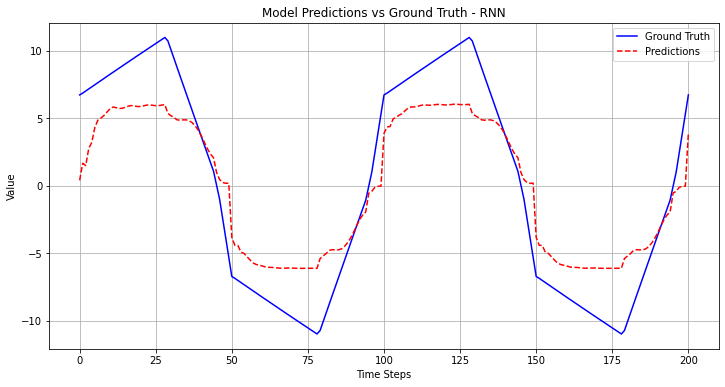

In [7]:
# Import matplotlib.pyplot
import matplotlib.pyplot as plt

# Convert predictions and ground truth to numpy arrays for plotting
predictions = test_outputs.numpy()[0]
ground_truth = y_test_tensor.numpy()[0]

# Create a figure with appropriate size
plt.figure(figsize=(12, 6))

# Plot ground truth
plt.plot(ground_truth, label='Ground Truth', color='blue')

# Plot predictions
plt.plot(predictions, label='Predictions', color='red', linestyle='--')

# Add labels and title
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.title('Model Predictions vs Ground Truth - RNN')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()


#### 4 Implement LSTM
* LayerNorm is applied
* Use AdamW optimize
* Use warmup lr scheduler

In [8]:
import torch
import torch.nn as nn
import math

class TimeSeriesLSTMModel(nn.Module):
    def __init__(self, input_size=2, hidden_size=16, num_layers=2, output_size=1):
        super(TimeSeriesLSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM layers with layer normalization
        self.lstm_layers = nn.ModuleList()
        self.layer_norms = nn.ModuleList()

        for i in range(num_layers):
            in_size = input_size if i == 0 else hidden_size
            self.lstm_layers.append(nn.LSTM(
                input_size=in_size,
                hidden_size=hidden_size,
                batch_first=True
            ))
            self.layer_norms.append(nn.LayerNorm(hidden_size))

        # Output projection
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        for i, (lstm, ln) in enumerate(zip(self.lstm_layers, self.layer_norms)):
            # x: (batch_size, seq_len, input_size)
            lstm_out, (h_n, c_n) = lstm(x)
            # lstm_out: (batch_size, seq_len, hidden_size)
            # h_n: (num_layers, batch_size, hidden_size)
            # c_n: (num_layers, batch_size, hidden_size)
            lstm_out = ln(lstm_out)
            # Residual connection if not the first layer and shapes match
            if i > 0 and x.shape == lstm_out.shape:
                x = x + lstm_out
            else:
                x = lstm_out
        return self.fc(x), None

# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

# Initialize the model
model = TimeSeriesLSTMModel()

# Define loss function and optimizer with weight decay (L2 regularization)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.003, weight_decay=1e-5)

# Training parameters
num_epochs = 200
batch_size = 10
warmup_epochs = 100

# Learning rate scheduler with warmup and cosine annealing
def get_lr(epoch):
    if epoch < warmup_epochs:
        return 0.001 * (epoch + 1) / warmup_epochs
    else:
        return 0.001 * 0.5 * (1 + math.cos(math.pi * (epoch - warmup_epochs) / (num_epochs - warmup_epochs)))

# Training loop with best model tracking
best_val_loss = float('inf')
best_model_state = None

for epoch in range(num_epochs):
    # Update learning rate
    for param_group in optimizer.param_groups:
        param_group['lr'] = get_lr(epoch)
    
    model.train()
    total_loss = 0
    
    # Mini-batch training
    for i in range(0, len(X_train_tensor), batch_size):
        batch_X = X_train_tensor[i:i+batch_size]
        batch_y = y_train_tensor[i:i+batch_size]
        
        # Forward pass
        outputs, _ = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs, _ = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
        
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], LR: {get_lr(epoch):.6f}, Train Loss: {total_loss/len(X_train_tensor):.4f}, Val Loss: {val_loss:.4f}')

# Load best model
model.load_state_dict(best_model_state)

# Calculate model size
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

# Test the model
model.eval()
with torch.no_grad():
    test_outputs, _ = model(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)
    print(f'Best Validation Loss: {best_val_loss:.4f}')
    print(f'Test Loss: {test_loss:.4f}')

Epoch [10/200], LR: 0.000100, Train Loss: 2.0097, Val Loss: 12.1172
Epoch [20/200], LR: 0.000200, Train Loss: 1.6598, Val Loss: 9.8917
Epoch [30/200], LR: 0.000300, Train Loss: 1.2781, Val Loss: 7.8435
Epoch [40/200], LR: 0.000400, Train Loss: 1.0610, Val Loss: 7.0011
Epoch [50/200], LR: 0.000500, Train Loss: 0.9085, Val Loss: 6.6063
Epoch [60/200], LR: 0.000600, Train Loss: 0.7960, Val Loss: 6.2117
Epoch [70/200], LR: 0.000700, Train Loss: 0.6518, Val Loss: 4.7681
Epoch [80/200], LR: 0.000800, Train Loss: 0.4963, Val Loss: 3.9830
Epoch [90/200], LR: 0.000900, Train Loss: 0.4096, Val Loss: 3.7848
Epoch [100/200], LR: 0.001000, Train Loss: 0.2947, Val Loss: 2.6284
Epoch [110/200], LR: 0.000980, Train Loss: 0.2489, Val Loss: 2.0017
Epoch [120/200], LR: 0.000914, Train Loss: 0.2197, Val Loss: 1.7628
Epoch [130/200], LR: 0.000806, Train Loss: 0.1988, Val Loss: 1.5613
Epoch [140/200], LR: 0.000669, Train Loss: 0.4615, Val Loss: 5.5518
Epoch [150/200], LR: 0.000516, Train Loss: 0.2570, Val L

Training MAE: 0.9255
Training MAE per sample - Avg: 0.9255, Min: 0.5123, Max: 2.3746
Validation MAE: 0.9263
Validation MAE per sample - Avg: 0.9263, Min: 0.4835, Max: 1.9015
Test MAE: 0.9060
Test MAE per sample - Avg: 0.9060, Min: 0.4723, Max: 1.7382
Average MAE: 0.9199


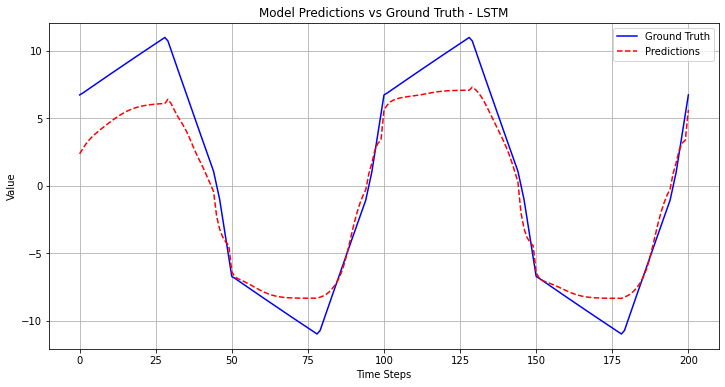

In [9]:
# Evaluate the RNN model on all datasets
evaluate_and_print_mae(model, X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, test_outputs, y_test_tensor)

# Import matplotlib.pyplot
import matplotlib.pyplot as plt

# Convert predictions and ground truth to numpy arrays for plotting
predictions = test_outputs.numpy()[0]
ground_truth = y_test_tensor.numpy()[0]

# Create a figure with appropriate size
plt.figure(figsize=(12, 6))

# Plot ground truth
plt.plot(ground_truth, label='Ground Truth', color='blue')

# Plot predictions
plt.plot(predictions, label='Predictions', color='red', linestyle='--')

# Add labels and title
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.title('Model Predictions vs Ground Truth - LSTM')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()


#### 5 Implement GRU
* LayerNorm is applied
* Use AdamW optimize
* Use warmup lr scheduler

In [10]:
import torch
import torch.nn as nn
import math

class TimeSeriesGRUModel(nn.Module):
    def __init__(self, input_size=2, hidden_size=16, num_layers=2, output_size=1):
        super(TimeSeriesGRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # GRU layers with layer normalization
        self.gru_layers = nn.ModuleList()
        self.layer_norms = nn.ModuleList()

        for i in range(num_layers):
            in_size = input_size if i == 0 else hidden_size
            self.gru_layers.append(nn.GRU(
                input_size=in_size,
                hidden_size=hidden_size,
                batch_first=True
            ))
            self.layer_norms.append(nn.LayerNorm(hidden_size))

        # Output projection
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        for i, (gru, ln) in enumerate(zip(self.gru_layers, self.layer_norms)):
            # x: (batch_size, seq_len, input_size)
            gru_out, h_n = gru(x)
            # gru_out: (batch_size, seq_len, hidden_size)
            # h_n: (num_layers, batch_size, hidden_size)
            gru_out = ln(gru_out)
            # Residual connection if not the first layer and shapes match
            if i > 0 and x.shape == gru_out.shape:
                x = x + gru_out
            else:
                x = gru_out
        return self.fc(x), None

# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

# Initialize the model
model = TimeSeriesGRUModel()

# Define loss function and optimizer with weight decay (L2 regularization)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.003, weight_decay=1e-5)

# Training parameters
num_epochs = 300
batch_size = 10
warmup_epochs = 50

# Learning rate scheduler with warmup and cosine annealing
def get_lr(epoch):
    if epoch < warmup_epochs:
        return 0.001 * (epoch + 1) / warmup_epochs
    else:
        return 0.001 * 0.5 * (1 + math.cos(math.pi * (epoch - warmup_epochs) / (num_epochs - warmup_epochs)))

# Training loop with best model tracking
best_val_loss = float('inf')
best_model_state = None

for epoch in range(num_epochs):
    # Update learning rate
    for param_group in optimizer.param_groups:
        param_group['lr'] = get_lr(epoch)
    
    model.train()
    total_loss = 0
    
    # Mini-batch training
    for i in range(0, len(X_train_tensor), batch_size):
        batch_X = X_train_tensor[i:i+batch_size]
        batch_y = y_train_tensor[i:i+batch_size]
        
        # Forward pass
        outputs, _ = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs, _ = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
        
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], LR: {get_lr(epoch):.6f}, Train Loss: {total_loss/len(X_train_tensor):.4f}, Val Loss: {val_loss:.4f}')

# Load best model
model.load_state_dict(best_model_state)

# Calculate model size
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

# Test the model
model.eval()
with torch.no_grad():
    test_outputs, _ = model(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)
    print(f'Best Validation Loss: {best_val_loss:.4f}')
    print(f'Test Loss: {test_loss:.4f}')

Epoch [10/300], LR: 0.000200, Train Loss: 1.8449, Val Loss: 11.0652
Epoch [20/300], LR: 0.000400, Train Loss: 1.4058, Val Loss: 8.4657
Epoch [30/300], LR: 0.000600, Train Loss: 1.0443, Val Loss: 6.8696
Epoch [40/300], LR: 0.000800, Train Loss: 0.8292, Val Loss: 6.2325
Epoch [50/300], LR: 0.001000, Train Loss: 0.6619, Val Loss: 5.1742
Epoch [60/300], LR: 0.000997, Train Loss: 0.5081, Val Loss: 4.2961
Epoch [70/300], LR: 0.000986, Train Loss: 0.3943, Val Loss: 3.5284
Epoch [80/300], LR: 0.000967, Train Loss: 0.2985, Val Loss: 2.6614
Epoch [90/300], LR: 0.000941, Train Loss: 0.2139, Val Loss: 2.0821
Epoch [100/300], LR: 0.000908, Train Loss: 0.1806, Val Loss: 1.9945
Epoch [110/300], LR: 0.000869, Train Loss: 0.1527, Val Loss: 1.8212
Epoch [120/300], LR: 0.000824, Train Loss: 0.1344, Val Loss: 1.7364
Epoch [130/300], LR: 0.000773, Train Loss: 0.1198, Val Loss: 1.6768
Epoch [140/300], LR: 0.000719, Train Loss: 0.1092, Val Loss: 1.6477
Epoch [150/300], LR: 0.000660, Train Loss: 0.1015, Val L

Training MAE: 0.5755
Training MAE per sample - Avg: 0.5755, Min: 0.2747, Max: 1.4851
Validation MAE: 0.7593
Validation MAE per sample - Avg: 0.7593, Min: 0.2629, Max: 2.7623
Test MAE: 0.8466
Test MAE per sample - Avg: 0.8466, Min: 0.2720, Max: 3.3850
Average MAE: 0.7120


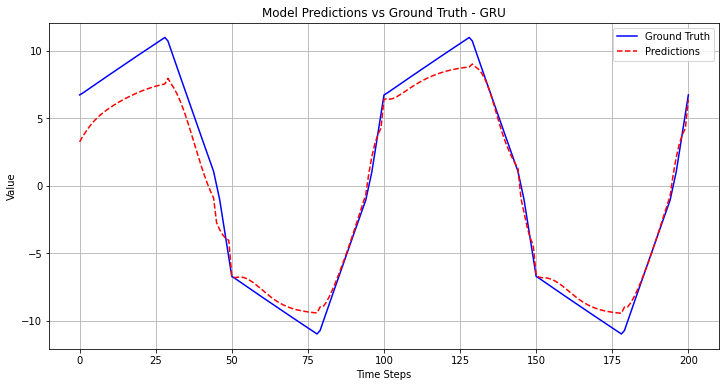

In [11]:
# Evaluate the RNN model on all datasets
evaluate_and_print_mae(model, X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, test_outputs, y_test_tensor)

# Import matplotlib.pyplot
import matplotlib.pyplot as plt

# Convert predictions and ground truth to numpy arrays for plotting
predictions = test_outputs.numpy()[0]
ground_truth = y_test_tensor.numpy()[0]

# Create a figure with appropriate size
plt.figure(figsize=(12, 6))

# Plot ground truth
plt.plot(ground_truth, label='Ground Truth', color='blue')

# Plot predictions
plt.plot(predictions, label='Predictions', color='red', linestyle='--')

# Add labels and title
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.title('Model Predictions vs Ground Truth - GRU')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()


#### 6 Implement BiLSTM
* LayerNorm is applied
* Use AdamW optimize
* Use warmup lr scheduler
* Understand why BiLSTM can be used in this case!
* You can achieve even higher accuracy with BiGRU

In [12]:
import torch
import torch.nn as nn
import math

class TimeSeriesBiLSTMModel(nn.Module):
    def __init__(self, input_size=2, hidden_size=16, num_layers=2, output_size=1):
        super(TimeSeriesBiLSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # BiLSTM layers with layer normalization
        self.lstm_layers = nn.ModuleList()
        self.layer_norms = nn.ModuleList()

        for i in range(num_layers):
            in_size = input_size if i == 0 else hidden_size * 2
            self.lstm_layers.append(nn.LSTM(
                input_size=in_size,
                hidden_size=hidden_size,
                batch_first=True,
                bidirectional=True
            ))
            self.layer_norms.append(nn.LayerNorm(hidden_size * 2))

        # Output projection
        self.fc = nn.Linear(hidden_size * 2, output_size)

    def forward(self, x):
        for i, (lstm, ln) in enumerate(zip(self.lstm_layers, self.layer_norms)):
            # x: (batch_size, seq_len, input_size)
            lstm_out, _ = lstm(x)
            # lstm_out: (batch_size, seq_len, hidden_size*2)
            lstm_out = ln(lstm_out)
            # Residual connection if not the first layer and shapes match
            if i > 0 and x.shape == lstm_out.shape:
                x = x + lstm_out
            else:
                x = lstm_out
        return self.fc(x), None

# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

# Initialize the model
model = TimeSeriesBiLSTMModel()

# Define loss function and optimizer with weight decay (L2 regularization)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.003, weight_decay=1e-5)

# Training parameters
num_epochs = 200
batch_size = 10
warmup_epochs = 50

# Learning rate scheduler with warmup and cosine annealing
def get_lr(epoch):
    if epoch < warmup_epochs:
        return 0.001 * (epoch + 1) / warmup_epochs
    else:
        return 0.001 * 0.5 * (1 + math.cos(math.pi * (epoch - warmup_epochs) / (num_epochs - warmup_epochs)))

# Training loop with best model tracking
best_val_loss = float('inf')
best_model_state = None

for epoch in range(num_epochs):
    # Update learning rate
    for param_group in optimizer.param_groups:
        param_group['lr'] = get_lr(epoch)
    
    model.train()
    total_loss = 0
    
    # Mini-batch training
    for i in range(0, len(X_train_tensor), batch_size):
        batch_X = X_train_tensor[i:i+batch_size]
        batch_y = y_train_tensor[i:i+batch_size]
        
        # Forward pass
        outputs, _ = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs, _ = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
        
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], LR: {get_lr(epoch):.6f}, Train Loss: {total_loss/len(X_train_tensor):.4f}, Val Loss: {val_loss:.4f}')

# Load best model
model.load_state_dict(best_model_state)

# Calculate model size
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

# Test the model
model.eval()
with torch.no_grad():
    test_outputs, _ = model(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)
    print(f'Best Validation Loss: {best_val_loss:.4f}')
    print(f'Test Loss: {test_loss:.4f}')

Epoch [10/200], LR: 0.000200, Train Loss: 2.2967, Val Loss: 14.0102
Epoch [20/200], LR: 0.000400, Train Loss: 1.4365, Val Loss: 8.4589
Epoch [30/200], LR: 0.000600, Train Loss: 0.8533, Val Loss: 5.2361
Epoch [40/200], LR: 0.000800, Train Loss: 0.5477, Val Loss: 3.5825
Epoch [50/200], LR: 0.001000, Train Loss: 0.3309, Val Loss: 2.1931
Epoch [60/200], LR: 0.000991, Train Loss: 0.1859, Val Loss: 1.3736
Epoch [70/200], LR: 0.000961, Train Loss: 0.1116, Val Loss: 0.8367
Epoch [80/200], LR: 0.000911, Train Loss: 0.0755, Val Loss: 0.7207
Epoch [90/200], LR: 0.000842, Train Loss: 0.0544, Val Loss: 0.5849
Epoch [100/200], LR: 0.000759, Train Loss: 0.0436, Val Loss: 0.5099
Epoch [110/200], LR: 0.000664, Train Loss: 0.0350, Val Loss: 0.4451
Epoch [120/200], LR: 0.000563, Train Loss: 0.0307, Val Loss: 0.4087
Epoch [130/200], LR: 0.000458, Train Loss: 0.0276, Val Loss: 0.3835
Epoch [140/200], LR: 0.000355, Train Loss: 0.0254, Val Loss: 0.3653
Epoch [150/200], LR: 0.000259, Train Loss: 0.0239, Val L

Training MAE: 0.3508
Training MAE per sample - Avg: 0.3508, Min: 0.2104, Max: 0.8677
Validation MAE: 0.4570
Validation MAE per sample - Avg: 0.4570, Min: 0.2523, Max: 0.8704
Test MAE: 0.4101
Test MAE per sample - Avg: 0.4101, Min: 0.2430, Max: 0.6797
Average MAE: 0.4005


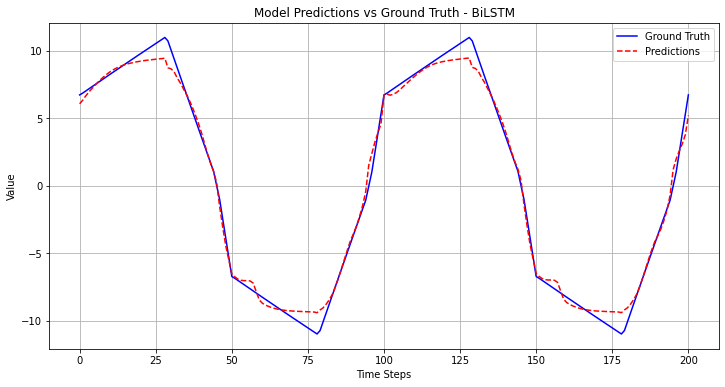

In [13]:
# Evaluate the RNN model on all datasets
evaluate_and_print_mae(model, X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, test_outputs, y_test_tensor)

# Import matplotlib.pyplot
import matplotlib.pyplot as plt

# Convert predictions and ground truth to numpy arrays for plotting
predictions = test_outputs.numpy()[0]
ground_truth = y_test_tensor.numpy()[0]

# Create a figure with appropriate size
plt.figure(figsize=(12, 6))

# Plot ground truth
plt.plot(ground_truth, label='Ground Truth', color='blue')

# Plot predictions
plt.plot(predictions, label='Predictions', color='red', linestyle='--')

# Add labels and title
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.title('Model Predictions vs Ground Truth - BiLSTM')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()


#### 7 Alternatives other than RNNs - Implement 1-D CNN
* LayerNorm is applied
* Use warmup lr scheduler
* A fixed window size is required

In [14]:
import torch
import torch.nn as nn
import math

class TimeSeriesCNN1DModel(nn.Module):
    def __init__(self, input_size=2, output_size=1, num_channels=32, 
        kernel_size=7, num_layers=3, seq_len=201):
        super(TimeSeriesCNN1DModel, self).__init__()
        self.seq_len = seq_len
        self.input_size = input_size

        layers = []
        in_channels = input_size
        for i in range(num_layers):
            out_channels = num_channels
            layers.append(nn.Conv1d(in_channels, out_channels, 
                kernel_size=kernel_size, padding=kernel_size//2))
            layers.append(nn.LayerNorm([out_channels, seq_len]))
            layers.append(nn.ReLU())
            in_channels = out_channels
        self.conv = nn.Sequential(*layers)
        self.fc = nn.Linear(num_channels, output_size)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        x = x.transpose(1, 2)  # (batch, input_size, seq_len)
        x = self.conv(x)       # (batch, num_channels, seq_len)
        x = x.transpose(1, 2)  # (batch, seq_len, num_channels)
        out = self.fc(x)       # (batch, seq_len, output_size)
        return out, None

# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

# Initialize the model
seq_len = X_train_tensor.shape[1]
input_size = X_train_tensor.shape[2]
output_size = y_train_tensor.shape[2] if y_train_tensor.ndim == 3 else 1
model = TimeSeriesCNN1DModel(input_size=input_size, output_size=output_size, seq_len=seq_len)

# Define loss function and optimizer with weight decay (L2 regularization)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.003, weight_decay=1e-5)

# Training parameters
num_epochs = 200
batch_size = 10
warmup_epochs = 100

# Learning rate scheduler with warmup and cosine annealing
def get_lr(epoch):
    if epoch < warmup_epochs:
        return 0.001 * (epoch + 1) / warmup_epochs
    else:
        return 0.001 * 0.5 * (1 + math.cos(math.pi * (epoch - warmup_epochs) / (num_epochs - warmup_epochs)))

# Training loop with best model tracking
best_val_loss = float('inf')
best_model_state = None

for epoch in range(num_epochs):
    # Update learning rate
    for param_group in optimizer.param_groups:
        param_group['lr'] = get_lr(epoch)
    
    model.train()
    total_loss = 0
    
    # Mini-batch training
    for i in range(0, len(X_train_tensor), batch_size):
        batch_X = X_train_tensor[i:i+batch_size]
        batch_y = y_train_tensor[i:i+batch_size]
        
        # Forward pass
        outputs, _ = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs, _ = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], LR: {get_lr(epoch):.6f}, Train Loss: {total_loss/len(X_train_tensor):.4f}, Val Loss: {val_loss:.4f}')

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)

# Calculate model size
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

# Test the model
model.eval()
with torch.no_grad():
    test_outputs, _ = model(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)
    print(f'Best Validation Loss: {best_val_loss:.4f}')
    print(f'Test Loss: {test_loss:.4f}')

Epoch [10/200], LR: 0.000100, Train Loss: 1.7807, Val Loss: 10.5717
Epoch [20/200], LR: 0.000200, Train Loss: 1.3792, Val Loss: 8.1916
Epoch [30/200], LR: 0.000300, Train Loss: 1.1717, Val Loss: 6.6135
Epoch [40/200], LR: 0.000400, Train Loss: 1.0028, Val Loss: 5.4831
Epoch [50/200], LR: 0.000500, Train Loss: 0.8488, Val Loss: 4.6560
Epoch [60/200], LR: 0.000600, Train Loss: 0.7081, Val Loss: 4.0449
Epoch [70/200], LR: 0.000700, Train Loss: 0.5785, Val Loss: 3.4602
Epoch [80/200], LR: 0.000800, Train Loss: 0.3825, Val Loss: 1.9638
Epoch [90/200], LR: 0.000900, Train Loss: 0.2193, Val Loss: 1.1447
Epoch [100/200], LR: 0.001000, Train Loss: 0.1284, Val Loss: 0.8058
Epoch [110/200], LR: 0.000980, Train Loss: 0.0795, Val Loss: 0.6776
Epoch [120/200], LR: 0.000914, Train Loss: 0.0602, Val Loss: 0.6201
Epoch [130/200], LR: 0.000806, Train Loss: 0.0469, Val Loss: 0.5497
Epoch [140/200], LR: 0.000669, Train Loss: 0.0398, Val Loss: 0.5032
Epoch [150/200], LR: 0.000516, Train Loss: 0.0352, Val L

Training MAE: 0.3941
Training MAE per sample - Avg: 0.3941, Min: 0.1455, Max: 1.1725
Validation MAE: 0.5023
Validation MAE per sample - Avg: 0.5023, Min: 0.1873, Max: 0.9922
Test MAE: 0.4780
Test MAE per sample - Avg: 0.4780, Min: 0.2304, Max: 0.9885
Average MAE: 0.4517


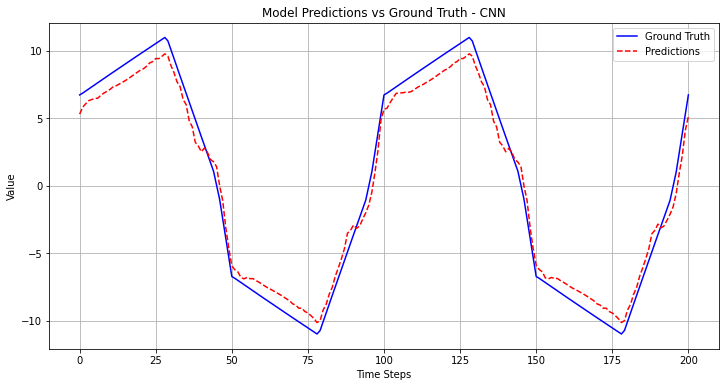

In [15]:
# Evaluate the CNN model on all datasets
evaluate_and_print_mae(model, X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, test_outputs, y_test_tensor)

# Import matplotlib.pyplot
import matplotlib.pyplot as plt

# Convert predictions and ground truth to numpy arrays for plotting
predictions = test_outputs.numpy()[0]
ground_truth = y_test_tensor.numpy()[0]

# Create a figure with appropriate size
plt.figure(figsize=(12, 6))

# Plot ground truth
plt.plot(ground_truth, label='Ground Truth', color='blue')

# Plot predictions
plt.plot(predictions, label='Predictions', color='red', linestyle='--')

# Add labels and title
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.title('Model Predictions vs Ground Truth - CNN')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()


#### 8 Alternatives other than RNNs - Implement iTransformer (Inverted Transformer)
* iTransformer treats each variate (feature) as a token instead of each time step
* Better for multivariate time series with cross-variate dependencies  
* Uses self-attention across variates rather than time steps
* More efficient than traditional transformers for time series

**Key Insights about iTransformer:**

1. **Inverted Architecture**: Unlike traditional transformers that apply attention across time steps, iTransformer applies attention across variates (features)
2. **Variate-as-Token**: Each variate (vp, vs) is treated as a token, and the time series values become the embedding dimension
3. **Cross-Variate Dependencies**: Captures relationships between different input features more effectively
4. **Scalability**: More efficient for multivariate time series as the attention complexity depends on the number of variates (2) rather than sequence length (201)
5. **Position Encoding**: Uses positional encoding to distinguish between different variates

**Comparison with RNNs/LSTMs:**
- RNNs process sequentially, iTransformer processes variates in parallel
- RNNs capture temporal dependencies, iTransformer captures cross-variate dependencies
- iTransformer can be more effective when feature interactions are important
- iTransformer typically performs well **when the data is sufficient!**


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(0), :]

class iTransformerBlock(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward=512, dropout=0.1):
        super(iTransformerBlock, self).__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, 
            dropout=dropout, batch_first=True)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, src):
        # Self-attention
        src2, _ = self.self_attn(src, src, src)
        src = src + self.dropout1(src2)
        src = self.norm1(src)
        
        # Feed forward
        src2 = self.linear2(self.dropout(F.relu(self.linear1(src))))
        src = src + self.dropout2(src2)
        src = self.norm2(src)
        return src

class TimeSeriesITransformerModel(nn.Module):
    def __init__(self, input_size=2, seq_len=201, d_model=128, nhead=8, num_layers=4, 
                 dim_feedforward=512, dropout=0.1, output_size=1):
        super(TimeSeriesITransformerModel, self).__init__()
        self.input_size = input_size
        self.seq_len = seq_len
        self.d_model = d_model
        self.output_size = output_size
        
        # Input embedding: each variate (feature) becomes a token
        # Input shape: (batch_size, seq_len, input_size)
        # We'll transpose to treat variates as sequence dimension
        self.input_projection = nn.Linear(seq_len, d_model)
        
        # Positional encoding for variates
        self.pos_encoding = PositionalEncoding(d_model, max_len=input_size)
        
        # iTransformer blocks
        self.transformer_blocks = nn.ModuleList([
            iTransformerBlock(d_model, nhead, dim_feedforward, dropout)
            for _ in range(num_layers)
        ])
        
        # Output projection
        self.output_projection = nn.Linear(d_model, seq_len)
        self.final_projection = nn.Linear(input_size, output_size)
        
        # Dropout
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        # x: (batch_size, seq_len, input_size)
        batch_size, seq_len, input_size = x.shape
        
        # Transpose to treat variates as tokens: (batch_size, input_size, seq_len)
        x = x.transpose(1, 2)
        
        # Project each variate's time series to d_model dimensions
        # x: (batch_size, input_size, d_model)
        x = self.input_projection(x)
        
        # Add positional encoding for variates
        # x: (input_size, batch_size, d_model) for pos encoding, then back to (batch_size, input_size, d_model)
        x = x.transpose(0, 1)
        x = self.pos_encoding(x)
        x = x.transpose(0, 1)
        
        # Apply dropout
        x = self.dropout(x)
        
        # Apply transformer blocks
        for transformer_block in self.transformer_blocks:
            x = transformer_block(x)
        
        # Project back to time series length
        # x: (batch_size, input_size, seq_len)
        x = self.output_projection(x)
        
        # Transpose back to (batch_size, seq_len, input_size)
        x = x.transpose(1, 2)
        
        # Final projection to output size
        # x: (batch_size, seq_len, output_size)
        x = self.final_projection(x)
        
        return x, None

# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

# Initialize the model
model = TimeSeriesITransformerModel()

# Define loss function and optimizer with weight decay (L2 regularization)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.003, weight_decay=1e-5)

# Training parameters
num_epochs = 200
batch_size = 10
warmup_epochs = 100

# Learning rate scheduler with warmup and cosine annealing
def get_lr(epoch):
    if epoch < warmup_epochs:
        return 0.001 * (epoch + 1) / warmup_epochs
    else:
        return 0.001 * 0.5 * (1 + math.cos(math.pi * (epoch - warmup_epochs) / (num_epochs - warmup_epochs)))

# Training loop with best model tracking
best_val_loss = float('inf')
best_model_state = None

for epoch in range(num_epochs):
    # Update learning rate
    for param_group in optimizer.param_groups:
        param_group['lr'] = get_lr(epoch)
    
    model.train()
    total_loss = 0
    
    # Mini-batch training
    for i in range(0, len(X_train_tensor), batch_size):
        batch_X = X_train_tensor[i:i+batch_size]
        batch_y = y_train_tensor[i:i+batch_size]
        
        # Forward pass
        outputs, _ = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs, _ = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
        
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], LR: {get_lr(epoch):.6f}, Train Loss: {total_loss/len(X_train_tensor):.4f}, Val Loss: {val_loss:.4f}')

# Load best model
model.load_state_dict(best_model_state)

# Calculate model size
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

# Test the model
model.eval()
with torch.no_grad():
    test_outputs, _ = model(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)
    print(f'Best Validation Loss: {best_val_loss:.4f}')
    print(f'Test Loss: {test_loss:.4f}')


Epoch [10/200], LR: 0.000100, Train Loss: 2.3654, Val Loss: 14.6640
Epoch [20/200], LR: 0.000200, Train Loss: 2.1038, Val Loss: 12.7647
Epoch [30/200], LR: 0.000300, Train Loss: 1.6655, Val Loss: 9.7976
Epoch [40/200], LR: 0.000400, Train Loss: 1.1160, Val Loss: 6.0595
Epoch [50/200], LR: 0.000500, Train Loss: 0.6124, Val Loss: 3.3170
Epoch [60/200], LR: 0.000600, Train Loss: 0.3287, Val Loss: 2.5711
Epoch [70/200], LR: 0.000700, Train Loss: 0.1947, Val Loss: 1.3970
Epoch [80/200], LR: 0.000800, Train Loss: 0.1412, Val Loss: 1.3986
Epoch [90/200], LR: 0.000900, Train Loss: 0.1311, Val Loss: 1.3010
Epoch [100/200], LR: 0.001000, Train Loss: 0.1240, Val Loss: 1.4712
Epoch [110/200], LR: 0.000980, Train Loss: 0.0750, Val Loss: 0.8871
Epoch [120/200], LR: 0.000914, Train Loss: 0.0638, Val Loss: 0.6431
Epoch [130/200], LR: 0.000806, Train Loss: 0.0582, Val Loss: 0.4533
Epoch [140/200], LR: 0.000669, Train Loss: 0.0372, Val Loss: 0.4791
Epoch [150/200], LR: 0.000516, Train Loss: 0.0287, Val 

Training MAE: 0.2834
Training MAE per sample - Avg: 0.2834, Min: 0.1283, Max: 0.9875
Validation MAE: 0.4182
Validation MAE per sample - Avg: 0.4182, Min: 0.1320, Max: 0.9033
Test MAE: 0.4079
Test MAE per sample - Avg: 0.4079, Min: 0.1883, Max: 0.9262
Average MAE: 0.3612


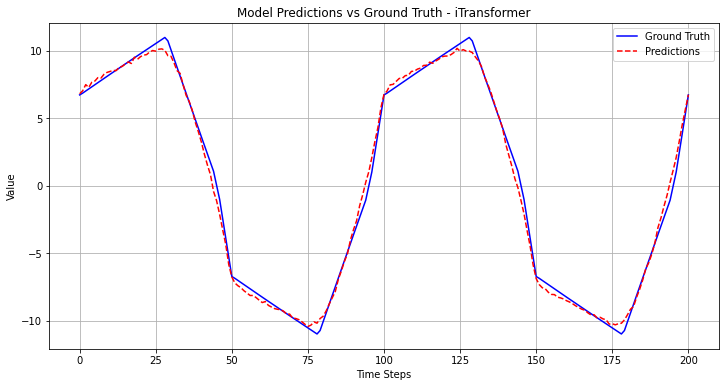

In [17]:
# Evaluate the iTransformer model on all datasets
evaluate_and_print_mae(model, X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, test_outputs, y_test_tensor)

# Import matplotlib.pyplot
import matplotlib.pyplot as plt

# Convert predictions and ground truth to numpy arrays for plotting
predictions = test_outputs.numpy()[0]
ground_truth = y_test_tensor.numpy()[0]

# Create a figure with appropriate size
plt.figure(figsize=(12, 6))

# Plot ground truth
plt.plot(ground_truth, label='Ground Truth', color='blue')

# Plot predictions
plt.plot(predictions, label='Predictions', color='red', linestyle='--')

# Add labels and title
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.title('Model Predictions vs Ground Truth - iTransformer')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()
